In [1]:
from matplotlib import pyplot as plt
import torch
from diffusion.approaches.ddpm.ddpm import DDPM
from diffusion.data.mnist_sampler import MNISTSampleable
from diffusion.architectures.res_unet import ResUnet

In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mps


In [3]:
sampeable = MNISTSampleable()


backbone = ResUnet(
    in_channels=1,
    channels=[16, 32, 64],
    num_classes=sampeable.num_classes,
    t_dim=64,
    y_dim=32,
    cond_dim=64,
).to(device)

ddpm = DDPM(
    backbone,
    device,
    timesteps=30,
    unconditional_label=sampeable.num_classes,
)

backbone.load_state_dict(torch.load("backbone_ddpm.pt"))

<All keys matched successfully>

30it [00:01, 25.25it/s]
30it [00:01, 18.93it/s]
30it [00:01, 20.11it/s]


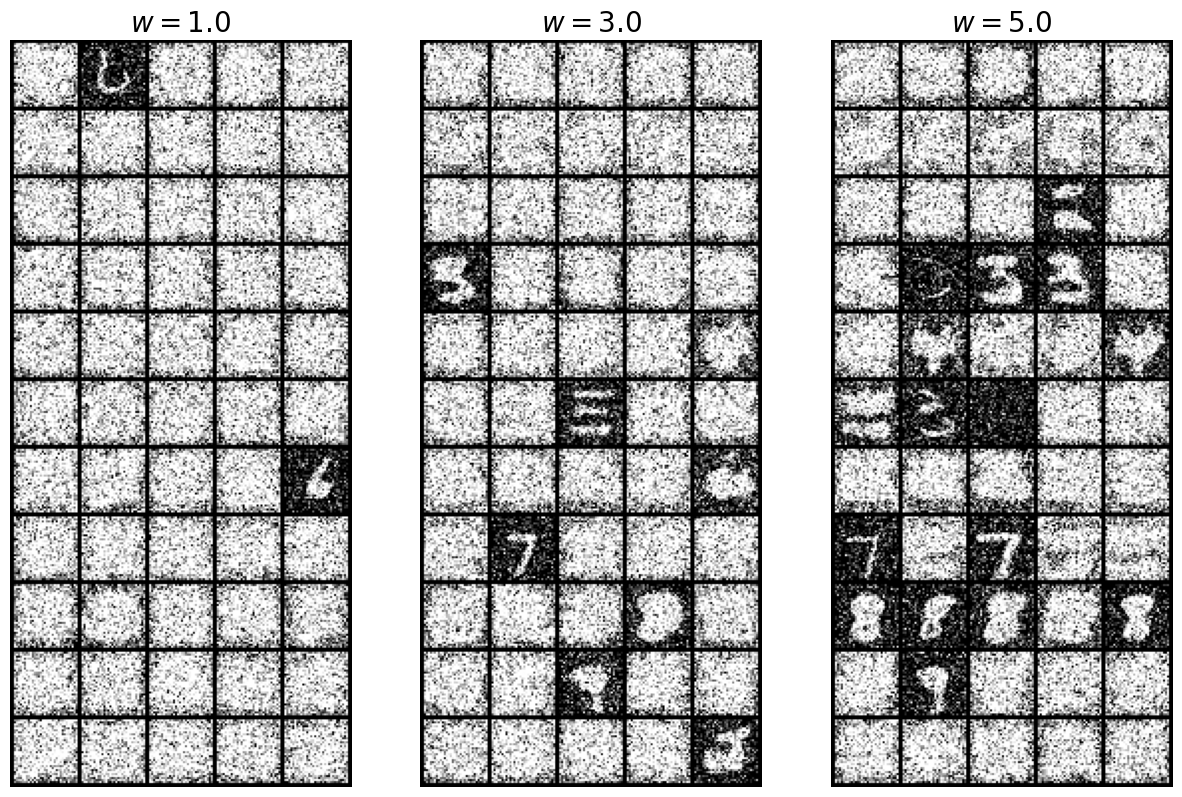

In [4]:
from torchvision.utils import make_grid

samples_per_class = 5  # 10
guidance_scales = [1.0, 3.0, 5.0]

fig, axes = plt.subplots(
    1, len(guidance_scales), figsize=(samples_per_class * len(guidance_scales), 10)
)

# Sample initial conditions
y = (
    torch.tensor([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10], dtype=torch.int64)
    .repeat_interleave(samples_per_class)
    .to(device)
)
num_samples = y.shape[0]

for idx, w in enumerate(guidance_scales):
    x1 = ddpm.sample(
        batch_size=num_samples,
        shape=(1, 32, 32),
        y=y,
        guidance_scale=w,
    )

    grid = make_grid(x1, nrow=samples_per_class, normalize=True, value_range=(-1, 1))
    axes[idx].imshow(grid.permute(1, 2, 0).cpu(), cmap="gray")
    axes[idx].axis("off")
    axes[idx].set_title(f"$w={w:.1f}$", fontsize=20)

plt.show()